In [2]:
%load_ext autoreload
%autoreload 2

In [14]:
from pathlib import Path
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

In [3]:
from trichomecounter.data.data import get_dataloader
from trichomecounter.utils.utils import get_model_instance_path, load_config, load_model

MODEL_NAME = "model0_density10"#"model0_density10"
CP = "best"
MODELS_DIR = PROJECT_ROOT /"models"

# Load config
model_dir = MODELS_DIR / MODEL_NAME
model_instance_path = get_model_instance_path(model_dir=model_dir, cp=CP)
config_path = model_instance_path / "config.yaml"
cfg = load_config(config_path)

# Create dataloader
test_dataloader = get_dataloader(split="test", cfg=cfg)

# Init model
model = load_model(model_name=MODEL_NAME, 
                    cp=CP) 

# Get device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\adria\OneDrive\Desktop\_\Programming\MachineLearning\TrichomeCounter\TrichomeCounter\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[WARNING] 'best' cp chosen. Should only be used for evaluation or transfer learning. Otherwise number of training epochs is logged incorrectly + optimizer has later state.
[INFO] Loaded model from 'C:\Users\adria\OneDrive\Desktop\_\Programming\MachineLearning\TrichomeCounter\TrichomeCounter\models\model0_density10\best_cp.pth'.


Original: 35
Pred: 45


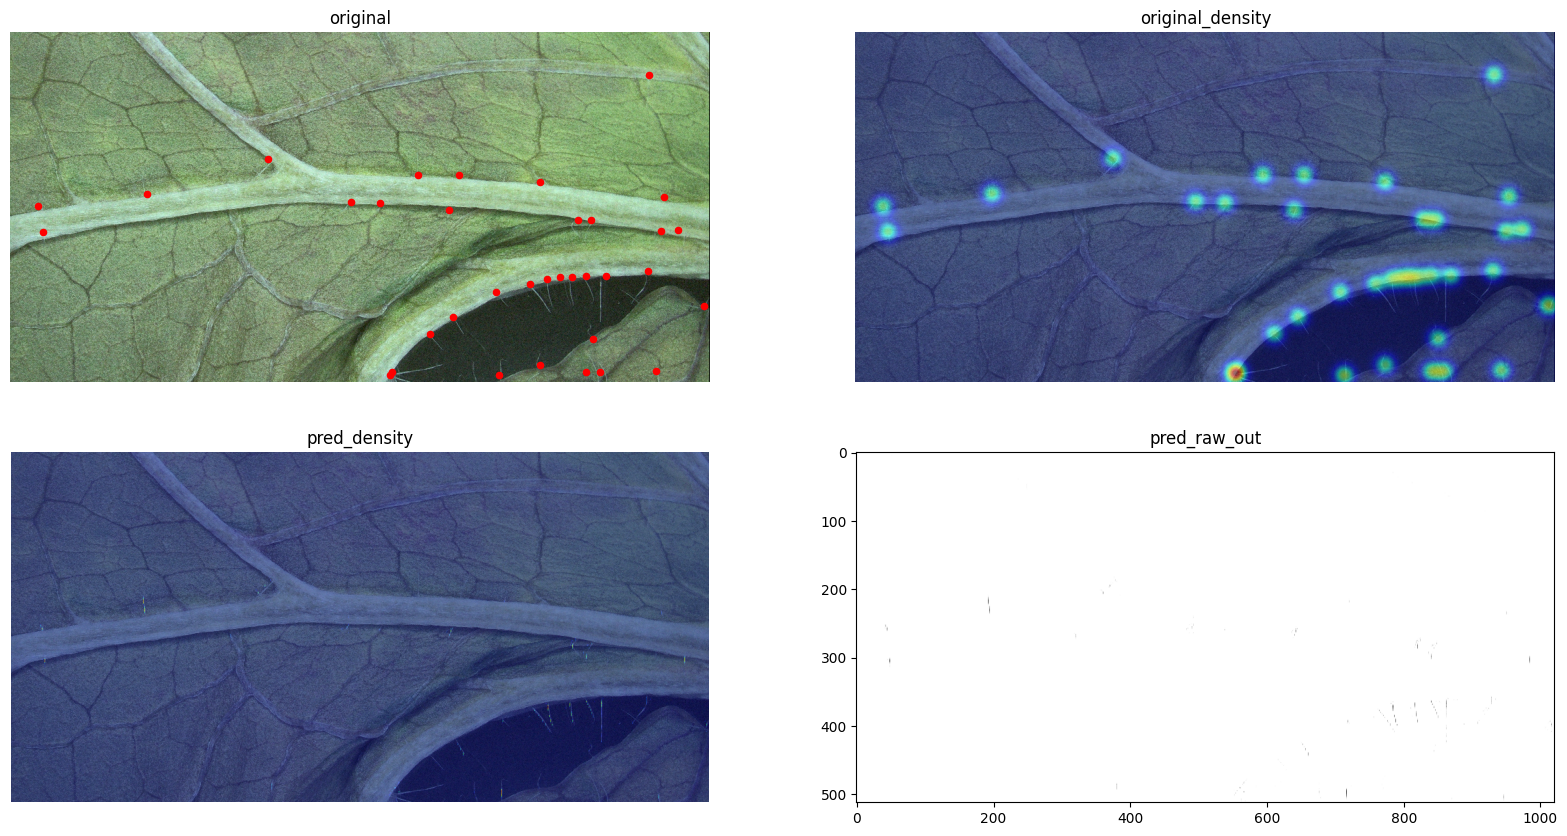

In [ ]:
from trichomecounter.utils.visualizations import plot_image, plot_density_map

#model0 = init_model("model1_density5", "density_model", cp="last")

test_images_batch, test_targetareas_batch, test_coords_batch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(test_images_batch), size=[1]).item()
img, targetarea, coords = test_images_batch[random_idx], test_targetareas_batch[random_idx], test_coords_batch[random_idx]
model.eval()
with torch.inference_mode():
    pred = model(img.unsqueeze(0))
    pred_density = pred["density"].squeeze().cpu().numpy()
    pred_density = pred_density[:,:-3] # TEST!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    pred_count = pred_density.sum()

print(f"Original: {len(coords)}")
print(f"Pred: {int(pred_count.item())}")

fig,ax = plt.subplots(2,2,figsize=(20,10))

plot_image(img, coords, title="original", ax=ax[0,0])
plot_density_map(targetarea.squeeze(0).numpy(), img, title="original_density", ax=ax[0,1])
plot_density_map(pred_density, img, title="pred_density", ax=ax[1,0])
ax[1,1].imshow(1-pred_density,cmap="gray")
ax[1,1].set_title("pred_raw_out");

(np.float64(-0.5), np.float64(1020.5), np.float64(511.5), np.float64(-0.5))

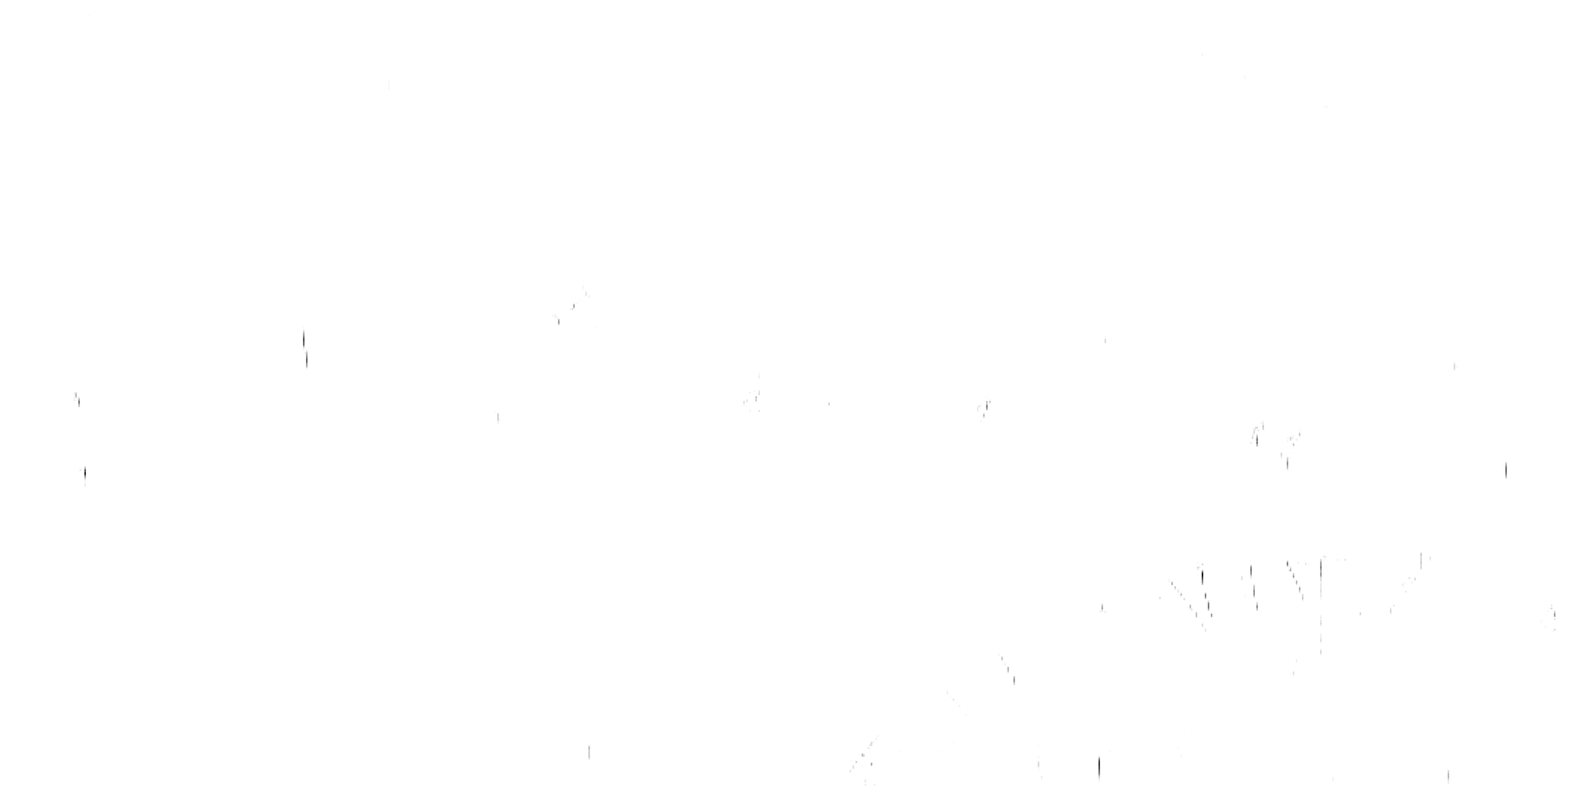

In [9]:
f,a = plt.subplots(figsize=(20,12))
plt.imshow(1-pred_density,cmap="gray")
plt.axis("off")

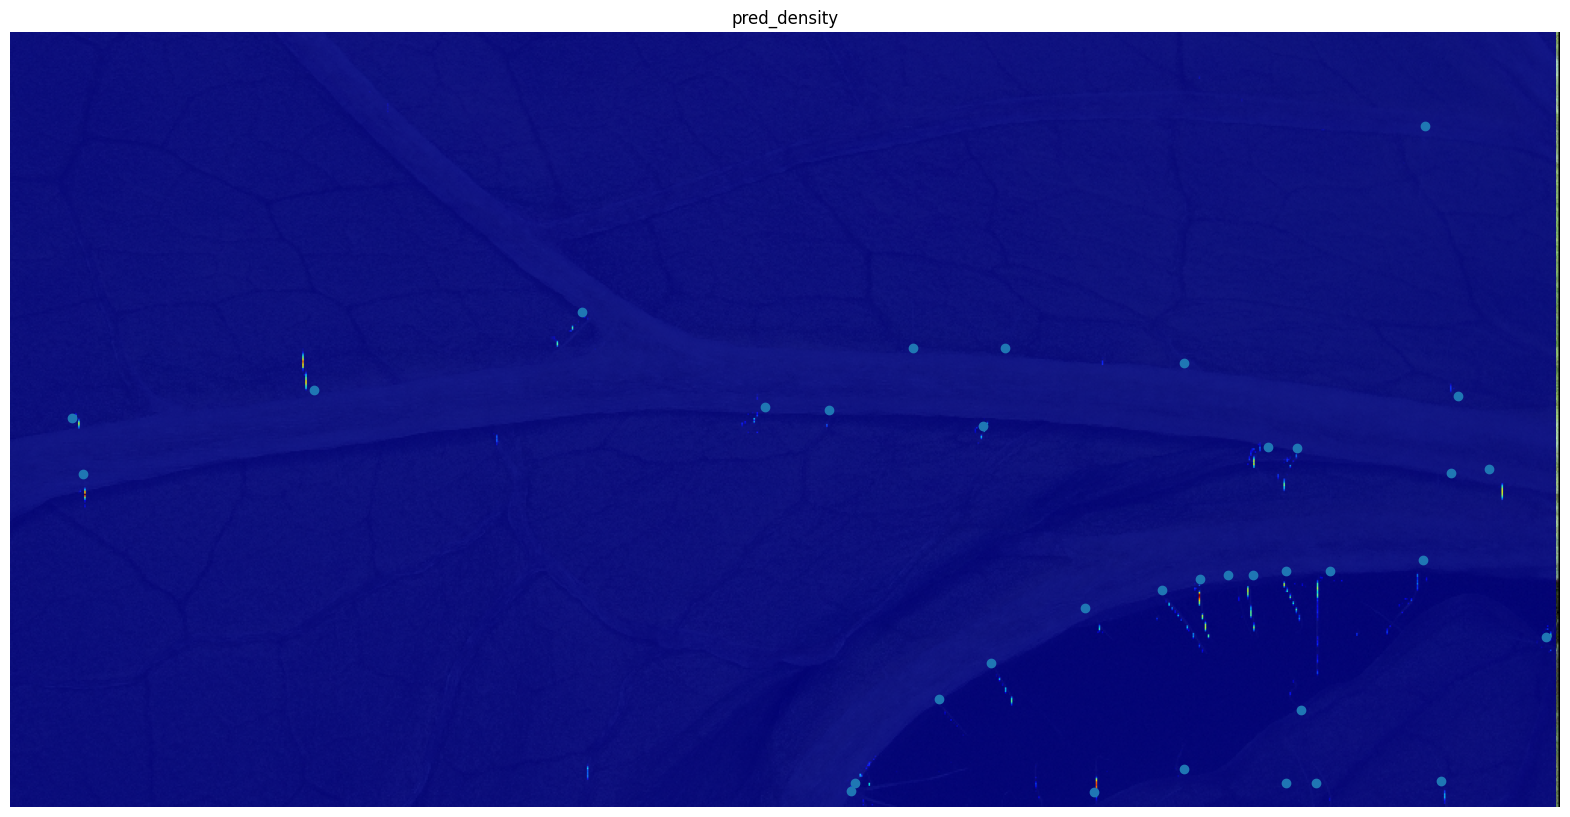

In [10]:
f,a = plt.subplots(figsize=(20,12))
plot_density_map(pred_density, img, title="pred_density", ax=a, alpha=0.9)

a.scatter(coords[:,0],coords[:,1])

Original: 67
Pred: 82


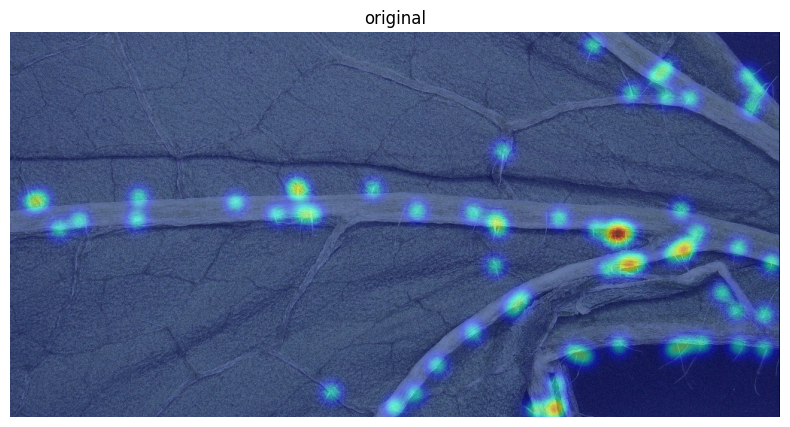

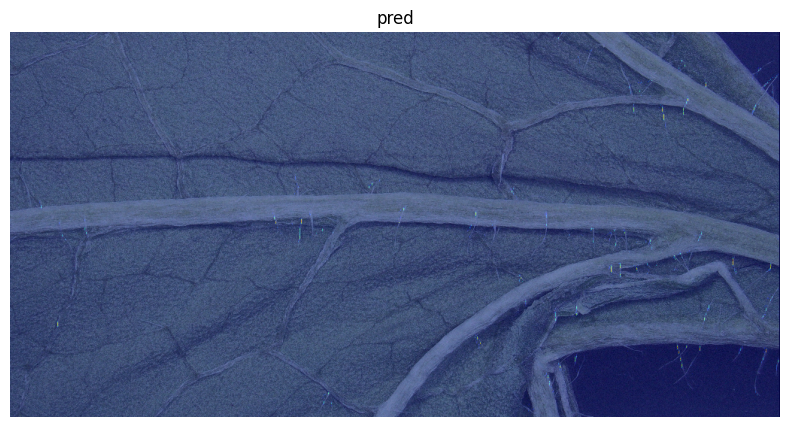

In [11]:
from trichomecounter.utils.visualizations import plot_density_map 
test_images_batch, test_targetareas_batch, test_coords_batch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(test_images_batch), size=[1]).item()
img, targetarea, coords = test_images_batch[random_idx], test_targetareas_batch[random_idx], test_coords_batch[random_idx]
model.eval()
with torch.inference_mode():
    pred = model(img.unsqueeze(0))["density"]
    pred_count = pred.sum(dim=[1, 2, 3])

print(f"Original: {len(coords)}")
print(f"Pred: {int(pred_count.item())}")
plot_density_map(targetarea.squeeze(0).numpy(), img, title=f"original")
plot_density_map(pred.squeeze().numpy(), img,  title=f"pred");

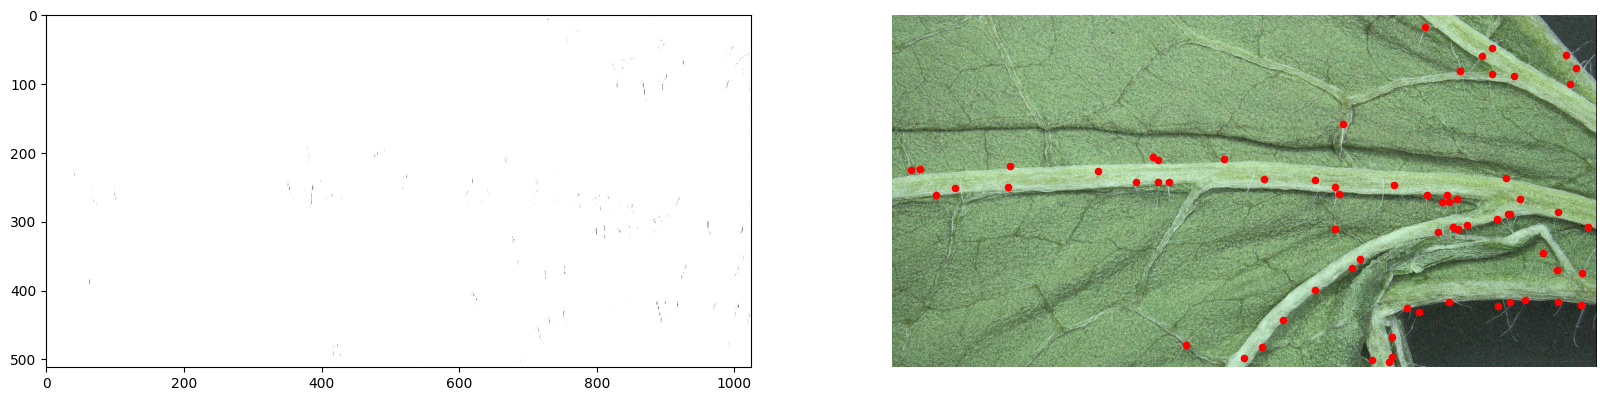

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(20,20))
p = pred.squeeze(0).squeeze(0).numpy()
ax[0].imshow(1-p,cmap="gray")
plot_image(img, coords,ax=ax[1])

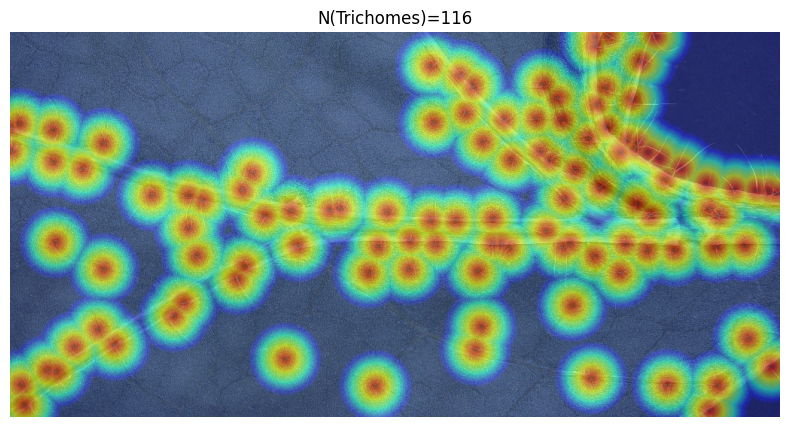

In [15]:
from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.utils.visualizations import plot_density_map
from trichomecounter.data.data_transformations import Compose, ResizeShortSide, RandomCrop


def generate_cone_map(coords, H, W, radius=50):
    
    # Initialize empty map
    targetarea = torch.zeros((H, W), dtype=torch.float32)


    # Return empty map if no coordinates provided
    if len(coords) == 0:
        return targetarea

    Y = torch.arange(H).view(1, H, 1).float()
    X = torch.arange(W).view(1, 1, W).float()
    
    cx = coords[:,0].view(-1,1,1)
    cy = coords[:,1].view(-1,1,1)

    dist = torch.sqrt((Y-cy)**2 + (X-cx)**2)
    values = 1.0 - dist / radius          # linear decay
    values = torch.clamp(values, 0.0, 1.0)

    targetarea = torch.amax(values, dim=0)
    targetarea = targetarea / targetarea.sum() * len(coords)

    return targetarea

# Inspect density map outcome
_, _, img_path, coord_path = get_random_data_paths()
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)

img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
coords = torch.from_numpy(coords).float()

# Resize for faster processing
#resize = Compose([ResizeShortSide(512),RandomCrop(512,512)])
resize = ResizeShortSide(512)
img, coords = resize(img, coords)

_, H, W = img.shape
density = generate_cone_map(coords, H, W)


trichome_count_actual = len(coords)
trichome_count_density = round(density.sum().item())

plot_density_map(density, img, title=f"N(Trichomes)={trichome_count_density}")

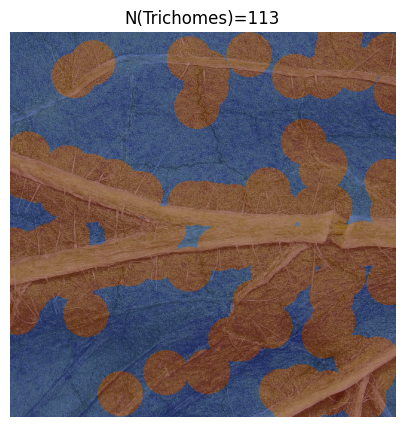

In [17]:
from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.utils.visualizations import plot_density_map
from trichomecounter.data.data_transformations import Compose, ResizeShortSide, RandomCrop

def generate_circle_map(coords, H, W, radius=30):
    
    # Initialize empty map
    targetarea = torch.zeros((H, W), dtype=torch.float32)


    # Return empty map if no coordinates provided
    if len(coords) == 0:
        return targetarea

    Y = torch.arange(H).view(1, H, 1)
    X = torch.arange(W).view(1, 1, W)

    cx = coords[:, 0].view(-1, 1, 1)
    cy = coords[:, 1].view(-1, 1, 1)

    dist2 = (X - cx)**2 + (Y - cy)**2
    targetarea = (dist2 <= radius**2).any(dim=0)
    targetarea = targetarea / targetarea.sum() * len(coords)

    return targetarea

# Inspect density map outcome
_, _, img_path, coord_path = get_random_data_paths()
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)

img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
coords = torch.from_numpy(coords).float()

# Resize for faster processing
resize = Compose([ResizeShortSide(512),RandomCrop(512,512)])
img, coords = resize(img, coords)

_, H, W = img.shape
density = generate_circle_map(coords, H, W)


trichome_count_actual = len(coords)
trichome_count_density = round(density.sum().item())

plot_density_map(density, img, title=f"N(Trichomes)={trichome_count_density}")

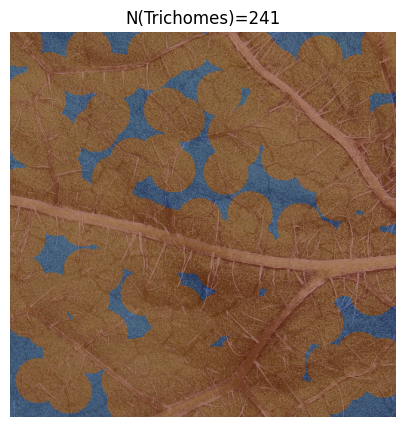

In [18]:
import torch
import torch.nn.functional as F

from trichomecounter.utils.utils import get_random_data_paths
from trichomecounter.utils.visualizations import plot_density_map
from trichomecounter.data.data_transformations import Compose, ResizeShortSide, RandomCrop

def generate_circle_map2(coords, H, W, radius=30):

    device = coords.device
    N = len(coords)
    if N == 0:
        return torch.zeros((H, W), dtype=torch.float32, device=device)

    r = int(radius)

    # Disk offsets, computed once -- shape (K, ) each, K ~ pi * r^2
    dy, dx = torch.meshgrid(
        torch.arange(-r, r + 1, device=device),
        torch.arange(-r, r + 1, device=device),
        indexing="ij"
    )
    disk = (dx ** 2 + dy ** 2) <= radius ** 2
    dx, dy = dx[disk], dy[disk]                      # (K,)

    # Broadcast every point against every offset at once: (N, K) -> (N*K,)
    xs = coords[:, 0].round().long()
    ys = coords[:, 1].round().long()
    abs_x = (xs[:, None] + dx[None, :]).reshape(-1)
    abs_y = (ys[:, None] + dy[None, :]).reshape(-1)

    # Drop anything that falls outside the image (handles clipping for free)
    valid = (abs_x >= 0) & (abs_x < W) & (abs_y >= 0) & (abs_y < H)
    abs_x, abs_y = abs_x[valid], abs_y[valid]

    # Coverage count per pixel -> union mask
    coverage = torch.zeros((H, W), dtype=torch.float32, device=device)
    coverage.index_put_((abs_y, abs_x),
                         torch.ones(abs_x.numel(), device=device),
                         accumulate=True)

    union_mask = coverage > 0
    U = union_mask.sum()
    if U == 0:
        return torch.zeros((H, W), dtype=torch.float32, device=device)

    return union_mask.float() * (N / U)


# Inspect density map outcome
_, _, img_path, coord_path = get_random_data_paths()
img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
coords = np.load(coord_path)

img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
coords = torch.from_numpy(coords).float()

# Resize for faster processing
resize = Compose([ResizeShortSide(512),RandomCrop(512,512)])
img, coords = resize(img, coords)

_, H, W = img.shape
density = generate_circle_map2(coords, H, W)


trichome_count_actual = len(coords)
trichome_count_density = round(density.sum().item())

plot_density_map(density, img, title=f"N(Trichomes)={trichome_count_density}")

In [21]:
from time import time
from trichomecounter.model.target_maps import generate_density_map

d1 = 0.0
d2 = 0.0

for i in range(50):
    _, _, img_path, coord_path = get_random_data_paths()
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    coords = np.load(coord_path)

    img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    coords = torch.from_numpy(coords).float()

    # Resize for faster processing
    resize = Compose([ResizeShortSide(512),RandomCrop(512,512)])
    img, coords = resize(img, coords)

    _, H, W = img.shape
    
    t1 = time()
    density = generate_circle_map2(coords, H, W)
    t2 = time()
    density = generate_density_map(coords,H,W,sigma=10)
    t3 = time()

    d1 += (t2-t1)
    d2 += (t3-t2)

print(f"> d1: {d1/50:.5f}")
print(f"> d2: {d2/50:.5f}")

> d1: 0.00507
> d2: 0.01191
